## Remember

Aprendizado de Máquina
1. Supervisionado = possui "gabarito"
- Regressão > Alvo (numérico)
- Classificação > Categórico
- Métricas de avaliação (baseadas em erros)
  - MAE (Erro médio absoluto) - Sensível a outliers
  - MSE e RMSE
  - R² = Métrica de suporte/Confiabilidade
- Y = Xn . w1 + w0  --> Regressão Linear
  - Correlação maior que 0,5
  - Parâmetros: w1 (coeficiente angular) e w0 (coeficiente linear)
    - O seu ajuste infere na acertabilidade do modelo
- Minimo Múltiplo Quadrado - MMQ
- Gradiente Descendente - GD
- Função de custo = Calcula o **erro**
- Todo modelo de IA tem parâmetros (pesos)
- Hiperparâmetro está por trás do modelo


## Modelos de Classificação

- As métricas aplicadas em modelos de regressão não podem ser aplicadas em modelos de classificação
- As saídas são classes
1. Supervisionados: Classificação e regressão
2. Não supervisionados: Clusterização

Exemplo: Classificar emails como SPAM ou não  
Solução: montar uma matriz de confusão para analisarmos o modelo - ela nos indica o quão bom está o modelo em prever exemplos de diversas classes  
- TP: Verdadeiro positivo (True Positive)
- TN: Verdadeiro negativo (True Negative)
- FP: Falso positivo (False Positive)
- FN: Falso negativo (False Negative)

Regressão Logística

In [29]:
# Veio do notebook do Marcones

# Importando as bibliotecas necessárias
# Metricas usadas para comparacoes

!pip install yellowbrick
from yellowbrick.classifier import ROCAUC
from sklearn.metrics import f1_score, ConfusionMatrixDisplay, RocCurveDisplay, confusion_matrix, classification_report, roc_auc_score, accuracy_score, precision_score, recall_score

# Importando o modelo que sera utilizado
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Carregamento de dados do OpenML
from sklearn.datasets import fetch_openml

# Plot dos gráficos
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import colors
import seaborn as sns

# Tratamento de dados
import pandas as pd
from collections import Counter

Métrica de Desempenho de Classificação

Vamos usar dados do https://www.openml.org/d/37  

Abaixo: Análise exploratória de dados

In [30]:
# Vamos carregar dados publicos
diabetes = fetch_openml(data_id=37)

In [31]:
# checando a dimensao dos dados recebidos
diabetes.data.shape

(768, 8)

In [32]:
# nome das features disponiveis
diabetes.feature_names

['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']

In [33]:
# Separando as colunas de features para analisar esses dados
dados = pd.DataFrame(data=diabetes.data, columns = diabetes.feature_names)

In [34]:
dados.head()

,preg,plas,pres,skin,insu,mass,pedi,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [35]:
dados.describe()

,preg,plas,pres,skin,insu,mass,pedi,age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


array([[<Axes: title={'center': 'preg'}>,
        <Axes: title={'center': 'plas'}>,
        <Axes: title={'center': 'pres'}>],
       [<Axes: title={'center': 'skin'}>,
        <Axes: title={'center': 'insu'}>,
        <Axes: title={'center': 'mass'}>],
       [<Axes: title={'center': 'pedi'}>,
        <Axes: title={'center': 'age'}>, <Axes: >]], dtype=object)

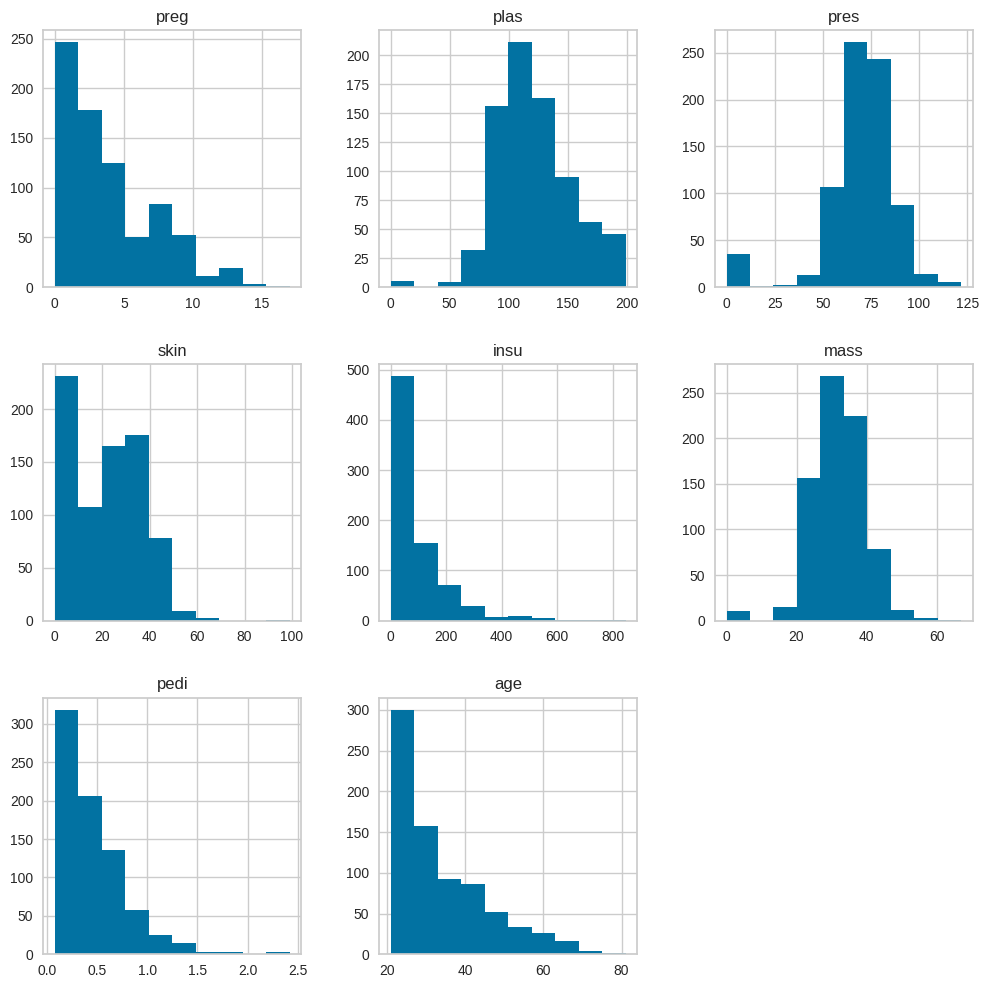

In [36]:
dados.hist(figsize=(12,12))

Alguns dos nossos dados não estão seguindo uma distribuição gaussiana. Assim, vamos ter que normalizar os nossos dados

## Criando o Modelo de Regressão Logística

In [37]:
# Vendo a distribuição das classes
Counter(diabetes.target)

Counter({'tested_positive': 268, 'tested_negative': 500})

Stratificação para balancear a quantidade de testes positivos e negativos (feito para o modelo não ficar "tendente" à classificação com maior quantidade)

In [38]:
# Dividindo os dados no conjunto de teste e treinamento
X_train, X_test, y_train, y_test = train_test_split(diabetes.data, diabetes.target, test_size=0.3, random_state=42)

# Aplicando a padronizacao
# levantando os minimos e maximos
scaler = MinMaxScaler().fit(X_train)
# Mudando a escala dos dados
x_train_scaled = scaler.transform(X_train)
x_test_scaled = scaler.transform(X_test)

# Fazendo a regressao logistica
log_reg = LogisticRegression()
log_reg.fit(x_train_scaled, y_train)

# Fazendo as predições
y_pred = log_reg.predict(x_test_scaled)

In [39]:
# Checando 20 primeiras saidas das previsoes
y_pred[:20]

array(['tested_negative', 'tested_negative', 'tested_negative',
       'tested_negative', 'tested_negative', 'tested_negative',
       'tested_negative', 'tested_negative', 'tested_positive',
       'tested_positive', 'tested_negative', 'tested_positive',
       'tested_negative', 'tested_negative', 'tested_negative',
       'tested_negative', 'tested_negative', 'tested_negative',
       'tested_positive', 'tested_negative'], dtype=object)

In [40]:
# Checando as 20 primeiras saidas dos labels
y_test[:20]

,class
668,tested_negative
324,tested_negative
624,tested_negative
690,tested_negative
473,tested_negative
204,tested_negative
97,tested_negative
336,tested_negative
568,tested_negative
148,tested_negative


In [41]:
# Comparando usando o DataFrame
pd.DataFrame({'pred': y_pred, 'resp': y_test})

,pred,resp
668,tested_negative,tested_negative
324,tested_negative,tested_negative
624,tested_negative,tested_negative
690,tested_negative,tested_negative
473,tested_negative,tested_negative
...,...,...
619,tested_negative,tested_positive
198,tested_negative,tested_positive
538,tested_negative,tested_negative
329,tested_negative,tested_negative


A boa notícia é que não precisamos comparar cada um dos dados manualmente. O próprio sklearn possui as métricas que aprendemos anteriormente.  

## Avaliando as métricas do nosso modelo

Analisar pelas classes se há discrepância na classificação

In [42]:
# Vendo a distribuição das classes
Counter(y_test)

Counter({'tested_negative': 151, 'tested_positive': 80})

In [43]:
# Vendo a distribuição das classes
Counter(y_pred)

Counter({'tested_negative': 162, 'tested_positive': 69})

Numa primeira análise, sem as métricas das aula, parece muito promissor o resultado obtido  

Vamos checar a matriz de confusao:

In [44]:
cm = confusion_matrix(y_test, y_pred, labels = ['tested_positive','tested_negative'])
cm

array([[ 45,  35],
       [ 24, 127]])

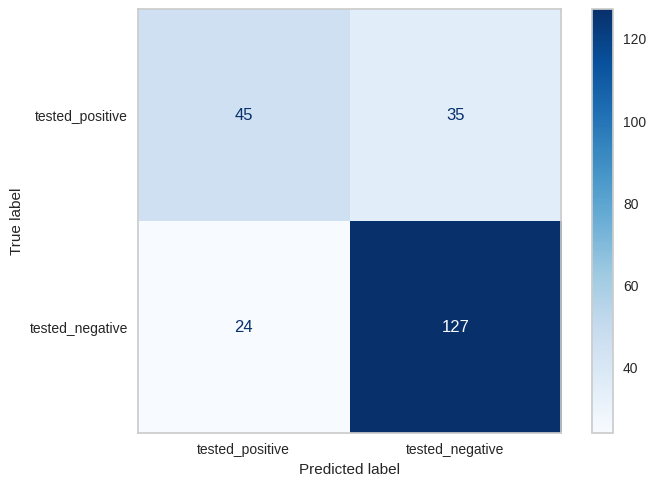

'\n | TP | FN |\n | FP | TN |\n '

In [45]:
# Vamos visulizar a figura da matriz de confusão

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['tested_positive','tested_negative'])
disp.plot(cmap='Blues')
plt.grid(False)
plt.show()

'''
 | TP | FN |
 | FP | TN |
 '''

Começando com a precisão:

$precisao = \frac{TP}{TP+FP}$

In [46]:
# Calculando a precisão para o "tested negative"
precision_score(y_test, y_pred, pos_label='tested_positive')

0.6521739130434783

In [47]:
# Precisao para o nosso modelo
precisao = 45/(45+24)
precisao

0.6521739130434783

Calculando a revocação:

$revocacao = \frac{TP}{TP+FN}$

In [48]:
recall_score(y_test, y_pred, pos_label='tested_positive')

0.5625

In [49]:
# revocacao para o nosso modelo
revocacao = 45/(45+35)
revocacao

0.5625

Calculando o f1 score:

$F_{1} = 2\times\frac{precisao \times revocacao}{precisao + revocacao}$

In [50]:
f1_score(y_test, y_pred, pos_label='tested_positive')

0.6040268456375839

In [51]:
# f1 score para o nosso modelo
f1 = 2*(precisao*revocacao)/(precisao+revocacao)
f1

0.6040268456375839

Calculando a acurácia:

$acuracia = \frac{TP+TN}{TP+TN+FP+FN}$

In [52]:
# Acuracia para o nosso modelo
accuracy_score(y_test, y_pred)

0.7445887445887446

In [53]:
# Comparando com o que vimos em aula
acuracia = (127+45)/(127+24+35+45)
acuracia

0.7445887445887446

**Exercício 1)** Recalcular as métricas de acurácia, revocação e f1 score do estudo acima considerando que a classe positiva dos nossos estudos é o 'tested_negative'

In [58]:
# Recalculando as métricas com 'tested_negative' como classe positiva

# Acurácia (não muda com a classe positiva)
accuracy_neg = accuracy_score(y_test, y_pred)
print(f"Acurácia ('tested_negative' como positivo): {accuracy_neg}")

# Revocação (Recall) para 'tested_negative'
recall_neg = recall_score(y_test, y_pred, pos_label='tested_negative')
print(f"Revocação ('tested_negative' como positivo): {recall_neg}")

# F1 Score para 'tested_negative'
f1_neg = f1_score(y_test, y_pred, pos_label='tested_negative')
print(f"F1 Score ('tested_negative' como positivo): {f1_neg}")

Acurácia ('tested_negative' como positivo): 0.7445887445887446
Revocação ('tested_negative' como positivo): 0.8410596026490066
F1 Score ('tested_negative' como positivo): 0.8115015974440895


A partir dos resultados, o que podemos concluir dos resultados do nosso modelo?

## Análise dos Resultados

Comparando as métricas com 'tested_positive' como classe positiva (resultados anteriores):

*   **Precisão:** 0.65
*   **Revocação:** 0.56
*   **F1 Score:** 0.60
*   **Acurácia:** 0.74

Comparando com 'tested_negative' como classe positiva (resultados do Exercício 1):

*   **Precisão:** (Para 'tested_negative' é 127 / (127 + 35) = 0.78) - *Note: A precisão para a classe 'tested_negative' não foi calculada explicitamente no exercício, mas pode ser inferida da matriz de confusão.*
*   **Revocação:** 0.84
*   **F1 Score:** 0.81
*   **Acurácia:** 0.74 (A acurácia não muda com a classe positiva)

**Conclusão:**

Ao considerar 'tested_negative' como a classe positiva, observamos um aumento significativo na Revocação (Recall) e no F1 Score. Isso significa que o modelo é melhor em identificar corretamente os casos negativos (pessoas que não têm diabetes) quando 'tested_negative' é a classe de interesse.

Por outro lado, quando 'tested_positive' é a classe positiva, a Revocação é menor, indicando que o modelo tem mais dificuldade em identificar corretamente todos os casos positivos (pessoas com diabetes).

A escolha de qual métrica é mais importante (Precisão ou Revocação) e qual classe deve ser considerada positiva depende do problema específico. Neste caso, se o custo de um falso negativo (prever que alguém não tem diabetes quando na verdade tem) for alto, talvez a Revocação para a classe 'tested_positive' precise ser melhorada, mesmo que isso custe um pouco na Precisão. Se o custo de um falso positivo (prever que alguém tem diabetes quando na verdade não tem) for alto, a Precisão para a classe 'tested_positive' seria mais crítica.

A Acurácia, que considera o desempenho geral do modelo, permanece a mesma, pois avalia o número total de previsões corretas em relação ao total de casos.

Para explorar ainda mais o desempenho do modelo, poderíamos analisar a curva ROC e o valor da AUC, que fornecem uma visão do trade-off entre a taxa de verdadeiros positivos e a taxa de falsos positivos em diferentes limiares de classificação.

Vamos agora checar a curva ROC do nosso modelo:

In [54]:
y_score = log_reg.predict_proba(x_test_scaled)
y_score.shape

(231, 2)

In [55]:
# Primeiro vamos levar o valor das probabilidades, isto é, os valores sem aplicarmos a classificacao.
y_score = log_reg.predict_proba(x_test_scaled)[:,1]
# Calculando o valor da AUC para o nosso modelo
roc_auc = roc_auc_score(y_test,y_score)
roc_auc

np.float64(0.796274834437086)

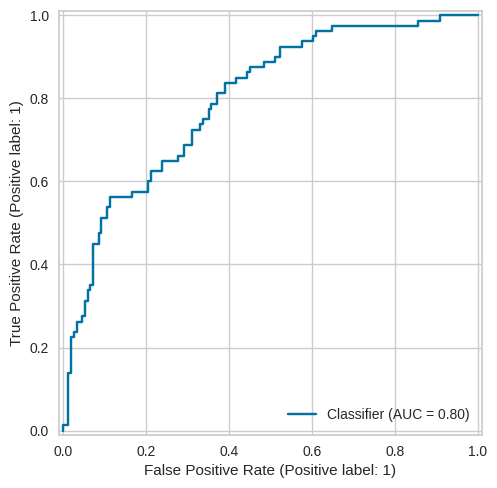

In [56]:
# prompt: plote a curva ROC

# Convert string labels to numerical values
y_test_numeric = [1 if label == 'tested_positive' else 0 for label in y_test]

RocCurveDisplay.from_predictions(y_test_numeric, y_score)
plt.show()